<a href="https://colab.research.google.com/github/hannahandkush/Coursework/blob/main/Assignment1_Hannah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Importing Dataset

In [14]:
pip install ucimlrepo

In [15]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

## 2. Splitting dataset into Training and Test sets

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
# Split the data into training and testing sets
# test_size=0.20 means 20% of the data will be used for testing, and 80% for training
# random_state ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (5197, 11)
Shape of X_test: (1300, 11)
Shape of y_train: (5197, 1)
Shape of y_test: (1300, 1)


## 3. Preprocessing pipeline


Feature Scaling, dimensionality reduction: feature Selection & feature Extraction, PCA created with 8 components

In [18]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [19]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

print("Feature scaling applied to X_train and X_test.")
display(X_train_scaled.head())

Feature scaling applied to X_train and X_test.


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,-0.468229,-0.599512,0.205467,0.464612,-0.712801,0.311659,0.343566,-0.296146,-0.168884,-1.083266,0.013766
1,0.851500,-0.352849,1.104063,-0.702999,1.067470,-1.408735,-1.847518,-0.203072,0.269679,0.598577,1.608717
2,0.385713,2.329612,-2.144710,-0.702999,0.234762,0.024927,-1.295294,-0.326062,1.209455,0.262208,1.105048
3,-1.555065,0.202143,0.067221,-0.890650,-0.798944,-1.007309,-0.618374,-1.492810,0.958848,-1.015992,1.021103
4,-0.468229,-0.476180,1.657046,2.070076,-0.081092,0.082273,0.450448,1.133204,-0.670098,-0.275981,-0.993572


In [20]:
from sklearn.feature_selection import SelectKBest, f_regression

# Instantiate SelectKBest with f_regression
selector = SelectKBest(score_func=f_regression, k='all')

# Fit the selector to the scaled training data
# y_train is flattened using values.ravel() to avoid warnings
selector.fit(X_train_scaled, y_train.values.ravel())

# Create a DataFrame to store feature names and their scores
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_
})

# Sort the features by score in descending order
feature_scores = feature_scores.sort_values(by='Score', ascending=False).reset_index(drop=True)

# Print the results
print("Feature Ranking based on f_regression scores:")
print(feature_scores)

Feature Ranking based on f_regression scores:
                 Feature        Score
0                alcohol  1307.654538
1                density   521.070721
2       volatile_acidity   386.682024
3              chlorides   199.376082
4            citric_acid    37.300947
5          fixed_acidity    22.566053
6    free_sulfur_dioxide    18.921498
7   total_sulfur_dioxide    12.800038
8              sulphates    11.285131
9         residual_sugar     9.135467
10                    pH     2.216389


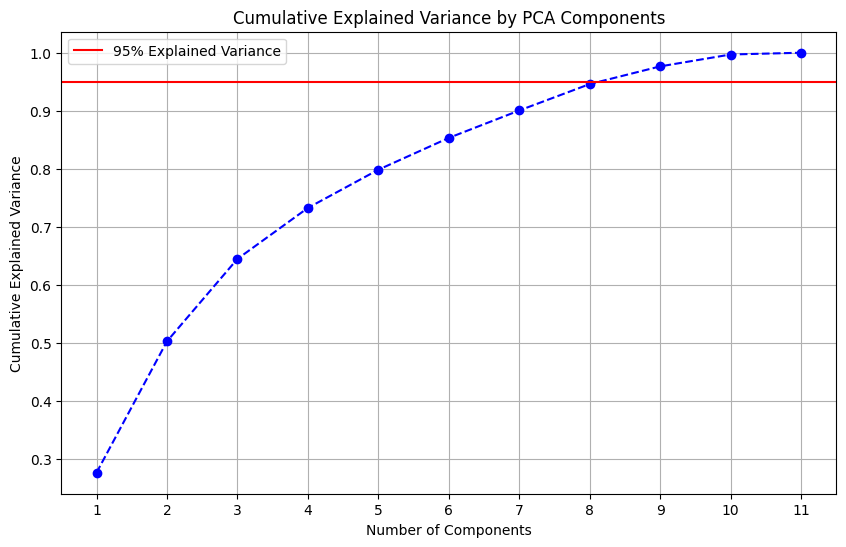

Cumulative Explained Variance Ratio:
Component 1: 0.2760
Component 2: 0.5025
Component 3: 0.6445
Component 4: 0.7325
Component 5: 0.7983
Component 6: 0.8531
Component 7: 0.9004
Component 8: 0.9459
Component 9: 0.9764
Component 10: 0.9969
Component 11: 1.0000


In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Initialize PCA to capture all components
pca = PCA()
pca.fit(X_train_scaled)

# Calculate cumulative explained variance
cumulative_variance = pca.explained_variance_ratio_.cumsum()

# Plotting the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')

# Add a horizontal line at 95% variance
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')

# Adding labels and title
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True)
plt.legend(loc='best')
plt.show()

# Print the variance ratios for reference
print("Cumulative Explained Variance Ratio:")
for i, var in enumerate(cumulative_variance):
    print(f"Component {i+1}: {var:.4f}")

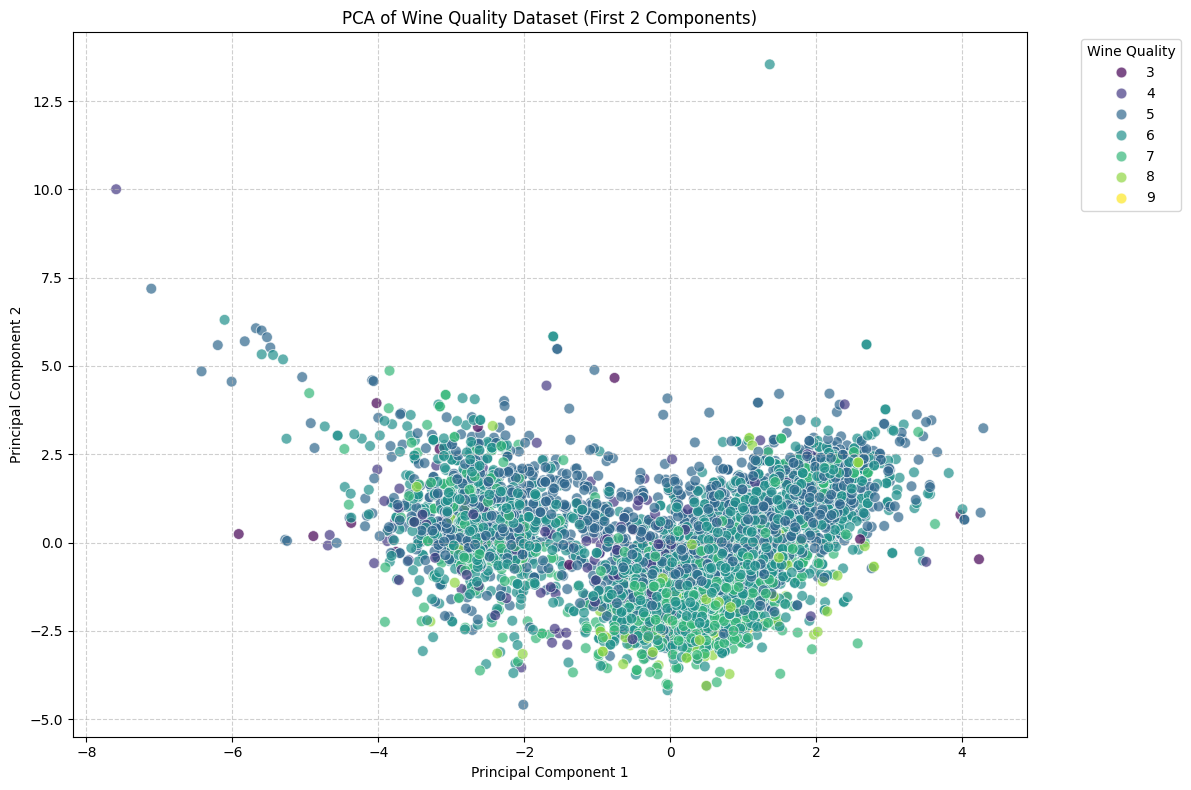

Explained variance ratio of first 2 components: [0.27600541 0.2264662 ]
Total variance captured by 2 components: 0.5025


In [22]:
import seaborn as sns

# 1. Initialize and fit PCA with 2 components
pca_2d = PCA(n_components=2)
pc_data = pca_2d.fit_transform(X_train_scaled)

# 2. Create a DataFrame for the components and quality
pca_df = pd.DataFrame(data=pc_data, columns=['PC1', 'PC2'])
pca_df['quality'] = y_train.values.ravel()

# 3-5. Create the scatter plot using seaborn for easy color mapping
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='quality',
    data=pca_df,
    palette='viridis',
    alpha=0.7,
    edgecolor='w',
    s=60
)

# Adding labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Wine Quality Dataset (First 2 Components)')
plt.legend(title='Wine Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Display the plot
plt.tight_layout()
plt.show()

# Summary of variance
print(f'Explained variance ratio of first 2 components: {pca_2d.explained_variance_ratio_}')
print(f'Total variance captured by 2 components: {sum(pca_2d.explained_variance_ratio_):.4f}')

In [23]:
from sklearn.decomposition import PCA

# 1. Initialize PCA with exactly 8 components
pca_8 = PCA(n_components=8)

# 2. Fit and transform the scaled training data
# X_train_scaled is already a DataFrame
X_train_pca = pca_8.fit_transform(X_train_scaled)

# 3. Transform the scaled testing data
# Ensure X_test_scaled is passed in the same format to avoid warnings
X_test_pca = pca_8.transform(X_test_scaled)

print(f"Original shape: {X_train_scaled.shape}")
print(f"Transformed training shape: {X_train_pca.shape}")
print(f"Transformed testing shape: {X_test_pca.shape}")
print(f"Total variance explained by 8 components: {sum(pca_8.explained_variance_ratio_):.4f}")

Original shape: (5197, 11)
Transformed training shape: (5197, 8)
Transformed testing shape: (1300, 8)
Total variance explained by 8 components: 0.9459


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [24]:
import pandas as pd

# Convert X_test_scaled from numpy array to DataFrame using X_train_scaled's column names
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train_scaled.columns)

# Verify the conversion
print("Standardized X_test_scaled format:")
display(X_test_scaled.head())
print(f"New shape: {X_test_scaled.shape}")

Standardized X_test_scaled format:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,-0.157705,-1.031172,2.901257,1.527971,-0.310805,-0.376498,0.183242,-0.163183,0.269679,-1.015992,1.440827
1,0.385713,1.867119,-0.762253,-0.682148,0.608045,0.082273,0.307938,0.302187,0.332330,-0.545076,-0.489903
2,-0.312967,0.325475,0.136344,0.402061,-1.028656,0.426352,0.307938,-0.854589,-0.231535,-0.612350,1.272938
3,-0.701122,-0.352849,1.034941,1.194368,-0.454375,1.745321,1.198623,0.408557,-0.607446,-0.141434,-0.825682
4,0.152820,0.078812,-0.831376,1.757323,-0.052378,1.860014,2.018053,1.392481,-0.670098,-0.208708,-1.329351


New shape: (1300, 11)


In [25]:
# 1. Initialize PCA with exactly 8 components
pca_8 = PCA(n_components=8)

# 2. Fit and transform the scaled training data
X_train_pca_array = pca_8.fit_transform(X_train_scaled)

# 3. Transform the standardized testing data
X_test_pca_array = pca_8.transform(X_test_scaled)

# 4. Convert results to DataFrames with column names PC1-PC8
pc_columns = [f'PC{i}' for i in range(1, 9)]
X_train_pca_df = pd.DataFrame(X_train_pca_array, columns=pc_columns)
X_test_pca_df = pd.DataFrame(X_test_pca_array, columns=pc_columns)

# 5. Verify results
print(f"X_train_pca_df shape: {X_train_pca_df.shape}")
print(f"X_test_pca_df shape: {X_test_pca_df.shape}")
display(X_train_pca_df.head())
print(f"Total variance explained by 8 components: {sum(pca_8.explained_variance_ratio_):.4f}")

X_train_pca_df shape: (5197, 8)
X_test_pca_df shape: (1300, 8)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,1.411246,-0.560914,0.029405,-0.544187,-0.232374,-0.309282,-0.153439,0.238502
1,-2.390616,-0.512137,1.961363,0.380885,-0.501618,-0.341160,0.210632,1.160430
2,-2.648557,-1.109949,-1.784121,-0.436466,0.158037,1.595453,-0.718105,-0.215019
3,-0.445566,-2.839953,-0.335750,-0.327142,-0.302133,-0.728812,-0.265008,0.845993
4,1.800617,1.992254,0.374142,-0.250878,-0.753145,-0.450687,0.475758,1.200622


Total variance explained by 8 components: 0.9459


## 4. Machine Learning Algorithm: SGDRegressor (Training)
In this section, we initialize the SGD model and perform a manual mini-batch gradient descent training loop.

In [27]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Instantiate the SGDRegressor with specific hyperparameters
sgd_regressor = SGDRegressor(
    max_iter=1000,
    alpha=0.01,
    learning_rate='constant',
    eta0=0.001,
    penalty='l2',
    random_state=42
)

# 2. Define training parameters
batch_size = 128
epochs = 50
mse_history = []
n_samples = X_train_pca_df.shape[0]

# 3. Manual training loop for Mini-batch Gradient Descent
for epoch in range(epochs):
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train_pca_df.iloc[indices]
    y_shuffled = y_train.values.ravel()[indices]

    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled.iloc[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]
        sgd_regressor.partial_fit(X_batch, y_batch)

        # Track MSE for the learning curve
        y_train_current_pred = sgd_regressor.predict(X_train_pca_df)
        mse_history.append(mean_squared_error(y_train, y_train_current_pred))

print("SGD Training completed.")

SGD Training completed.


## 5. Model Evaluation: SGDRegressor (Testing)
Now we evaluate the performance of our fine-tuned SGD model on the unseen test dataset to check for generalization.

In [28]:
from sklearn.metrics import mean_squared_error

# Final Evaluation on Test Data
y_test_pred_sgd = sgd_regressor.predict(X_test_pca_df)
test_mse_sgd = mean_squared_error(y_test, y_test_pred_sgd)

print(f"--- SGD Regressor Final Test Evaluation ---")
print(f"Baseline MSE: 0.7684")
print(f"Test MSE: {test_mse_sgd:.4f}")

if test_mse_sgd < 0.7684:
    print("\nSuccess: The model outperforms the baseline on the test set.")

--- SGD Regressor Final Test Evaluation ---
Baseline MSE: 0.7684
Test MSE: 0.5636

Success: The model outperforms the baseline on the test set.


In [26]:
# BASELINE MSE CALCULATION
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate the mean of the training target variable
mean_y_train = y_train.mean()

# Create a baseline prediction by using the mean for all training samples
y_train_baseline_pred = np.full(y_train.shape, mean_y_train)

# Calculate the Mean Squared Error (MSE) for the baseline model
baseline_mse = mean_squared_error(y_train, y_train_baseline_pred)

print(f"Mean baseline MSE for the training data: {baseline_mse:.4f}")

Mean baseline MSE for the training data: 0.7684


## 6. Model Performance Visualization
In this section, we visualize the model's accuracy on the test set and its convergence during training.

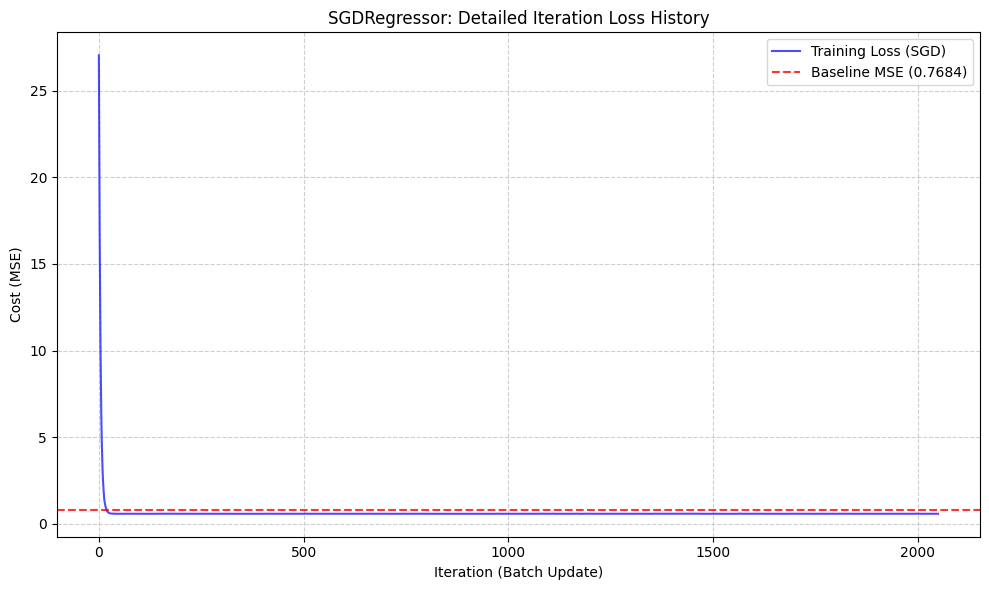

Total Iterations: 2050
Initial MSE: 27.0545
Final MSE: 0.5739


In [34]:
import matplotlib.pyplot as plt

# 1. Plotting the full iteration history (batch updates) for SGDRegressor
plt.figure(figsize=(10, 6))
plt.plot(range(len(mse_history)), mse_history, label='Training Loss (SGD)', color='blue', alpha=0.7)

# 2. Adding the Baseline for context
plt.axhline(y=0.7684, color='red', linestyle='--', label='Baseline MSE (0.7684)', alpha=0.8)

# 3. Adding labels and title
plt.xlabel('Iteration (Batch Update)')
plt.ylabel('Cost (MSE)')
plt.title('SGDRegressor: Detailed Iteration Loss History')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 4. Display the plot
plt.tight_layout()
plt.show()

print(f"Total Iterations: {len(mse_history)}")
print(f"Initial MSE: {mse_history[0]:.4f}")
print(f"Final MSE: {mse_history[-1]:.4f}")

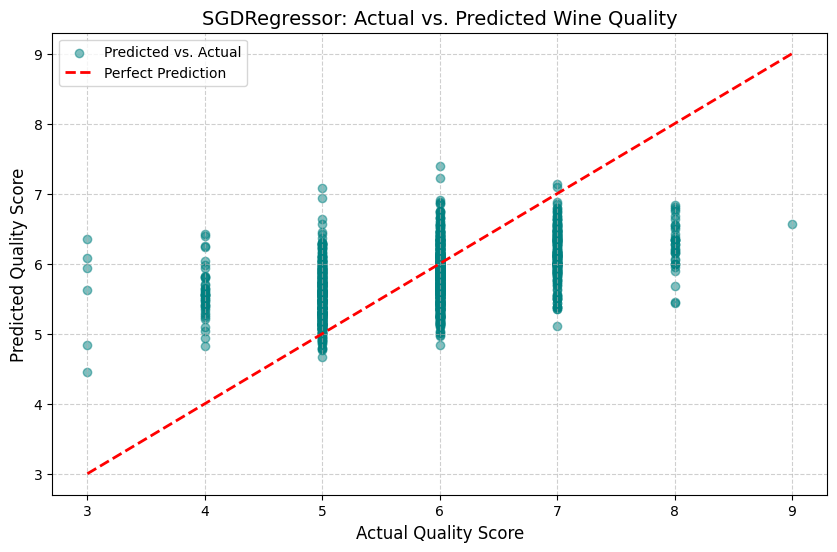

In [40]:
import matplotlib.pyplot as plt

# 1. Create the figure
plt.figure(figsize=(10, 6))

# 2. Plot Actual vs Predicted
plt.scatter(y_test, y_test_pred_sgd, alpha=0.5, color='teal', label='Predicted vs. Actual')

# 3. Add a 45-degree line for reference (Perfect Prediction)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2, label='Perfect Prediction')

# 4. Add labels, title, and formatting
plt.title('SGDRegressor: Actual vs. Predicted Wine Quality', fontsize=14)
plt.xlabel('Actual Quality Score', fontsize=12)
plt.ylabel('Predicted Quality Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Show plot
plt.show()

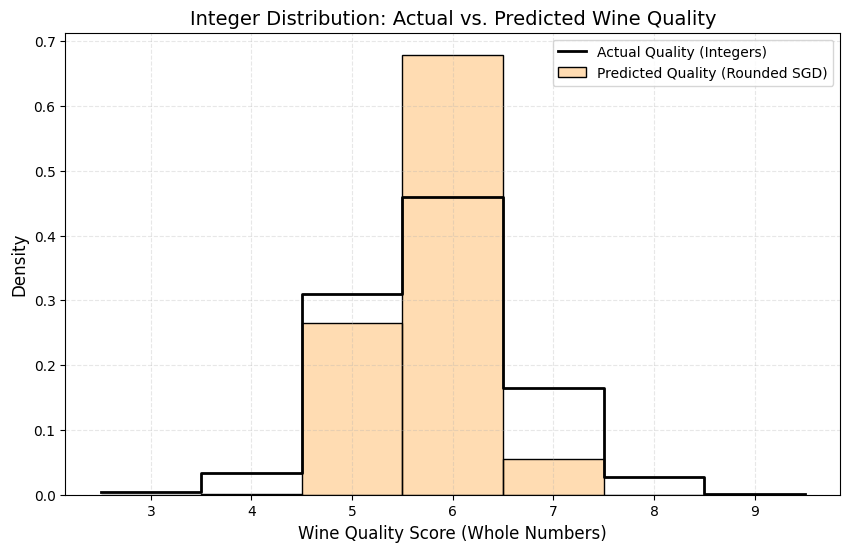

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize the plot
plt.figure(figsize=(10, 6))

# 2. Define bins to align with whole numbers (integers 3 to 9)
bins = np.arange(3, 11) - 0.5

# 3. Plot the Actual Quality as a histogram (Step line for clarity)
sns.histplot(y_test.values.ravel(), bins=bins, label='Actual Quality (Integers)',
             color='black', element='step', fill=False, stat='density', lw=2)

# 4. Plot the Predicted Quality (SGDRegressor) rounded to nearest integer
# This shows how the model's 'bets' look when forced to pick a whole number
sns.histplot(np.round(y_test_pred_sgd), bins=bins, label='Predicted Quality (Rounded SGD)',
             color='darkorange', element='bars', alpha=0.3, stat='density')

# 5. Formatting labels and title
plt.title('Integer Distribution: Actual vs. Predicted Wine Quality', fontsize=14)
plt.xlabel('Wine Quality Score (Whole Numbers)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xticks(range(3, 10))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

# 6. Show the plot
plt.show()

## Extra: Alternative Machine Learning Algorithm Comparison
Random Forest Regressor and AdalineSGD





In [29]:
# Model created with RandomForestRegressor to predict a continuous numerical value

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. Initialize the Random Forest Regressor
# We use random_state for reproducibility
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model on the PCA-transformed training data
# y_train needs to be flattened to (n_samples,)
rf_model.fit(X_train_pca_df, y_train.values.ravel())

# 3. Predict on the training set to compare with baseline
y_train_pred = rf_model.predict(X_train_pca_df)

# 4. Calculate the MSE
train_mse = mean_squared_error(y_train, y_train_pred)

print(f"Mean baseline MSE: 0.7684")
print(f"Random Forest Training MSE: {train_mse:.4f}")
print(f"Improvement: {0.7684 - train_mse:.4f}")

Mean baseline MSE: 0.7684
Random Forest Training MSE: 0.0544
Improvement: 0.7140


In [31]:
import numpy as np
from sklearn.metrics import mean_squared_error

class AdalineSGD:
    def __init__(self, eta=0.01, n_iter=50, shuffle=True, random_state=None):
        self.eta = eta
        self.n_iter = n_iter
        self.w_initialized = False
        self.shuffle = shuffle
        self.random_state = random_state

    def fit(self, X, y, X_test=None, y_test=None):
        self._initialize_weights(X.shape[1])
        self.train_mse_ = []
        self.test_mse_ = []
        self.epoch_predictions_ = []

        y = y.values.ravel() if hasattr(y, 'values') else y.ravel()
        # Correcting null check to None
        if y_test is not None:
            y_test = y_test.values.ravel() if hasattr(y_test, 'values') else y_test.ravel()

        for i in range(self.n_iter):
            if self.shuffle:
                X, y = self._shuffle(X, y)

            for xi, target in zip(X.values if hasattr(X, 'values') else X, y):
                self._update_weights(xi, target)

            # Track metrics after each epoch
            y_train_pred = self.predict(X)
            self.train_mse_.append(mean_squared_error(y, y_train_pred))

            if X_test is not None and y_test is not None:
                y_test_pred = self.predict(X_test)
                self.test_mse_.append(mean_squared_error(y_test, y_test_pred))
                self.epoch_predictions_.append(y_test_pred[:10])

        return self

    def _shuffle(self, X, y):
        r = self.rgen.permutation(len(y))
        return X.iloc[r] if hasattr(X, 'iloc') else X[r], y[r]

    def _initialize_weights(self, m):
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01, size=m)
        self.b_ = 0.0  # Fixed: replaced np.float_(0.) with 0.0
        self.w_initialized = True

    def _update_weights(self, xi, target):
        output = self.activation(self.net_input(xi))
        error = (target - output)
        # Gradient descent update for MSE: w = w + eta * 2 * error * x
        self.w_ += self.eta * 2.0 * xi * error
        self.b_ += self.eta * 2.0 * error

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        return X

    def predict(self, X):
        return self.activation(self.net_input(X))

print("AdalineSGD refactored for Regression (with NumPy 2.0 fix).")

AdalineSGD refactored for Regression (with NumPy 2.0 fix).


In [33]:
# Instantiate and train the refactored AdalineSGD regressor
ada_reg = AdalineSGD(eta=0.001, n_iter=50, random_state=42)

# Train the model using the PCA-transformed training and test sets
ada_reg.fit(X_train_pca_df, y_train, X_test_pca_df, y_test)

print(f'AdalineSGD training completed over {ada_reg.n_iter} iterations.')
print(f'Final Training MSE: {ada_reg.train_mse_[-1]:.4f}')
print(f'Final Test MSE: {ada_reg.test_mse_[-1]:.4f}')
# Display sample predictions from the last epoch
print(f'Sample predictions (first 10 of last epoch): {ada_reg.epoch_predictions_[-1]}')

AdalineSGD training completed over 50 iterations.
Final Training MSE: 0.5785
Final Test MSE: 0.5638
Sample predictions (first 10 of last epoch): [6.58858633 5.09206916 6.2917722  5.84131654 5.35602891 6.03526052
 6.05374661 5.75347651 5.16869468 6.16592584]
